# M82 Cooling-Flow Walkthrough

This notebook gives a single end-to-end, physics-motivated tour of the current float-native cooling-flow stack.
It builds an M82-motivated halo at `z = 0`, computes a spherical cooling-flow family by sweeping over sonic radius,
compares the resulting radial profiles directly, and then drills into low- and high-`Mdot` examples.

The main solver setup follows the spherical approximation described in the draft:
the cooling-flow solutions use an NFW halo + outer halo + spherical stellar component.
A Miyamoto-Nagai stellar disk is included separately to show how the spherical solver potential connects to the
disk-like potential used in simulations.

Some requested `R_sonic` values do not produce an accepted transonic solution with the current solver and parameter set.
Those radii are kept in the sweep and shown explicitly as gaps rather than being trimmed away.


In [1]:
import io
import math
import sys
import warnings
from contextlib import redirect_stdout
from pathlib import Path

def _find_repo_root():
    for start in (Path.cwd(), Path.cwd().resolve()):
        for candidate in (start, *start.parents):
            if (candidate / 'pysrc' / 'solve_ode.py').exists():
                return candidate
    raise RuntimeError('Could not find repo root containing pysrc/solve_ode.py')

repo_root = _find_repo_root()
pysrc_path = repo_root / 'pysrc'
if str(pysrc_path) not in sys.path:
    sys.path.insert(0, str(pysrc_path))

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

import solve_ode as CF
import HaloPotential_new as Halo
import WiersmaCooling as Cool
from analytic_models import RotationConfig, TurbulenceConfig, maximum_hot_mode_accretion_rate
from cosmology import DEFAULT_COSMOLOGY

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass


In [2]:
def print_table(rows, columns=None, float_precision=3):
    if not rows:
        print('(no rows)')
        return

    if columns is None:
        columns = list(rows[0].keys())

    def format_value(value):
        if isinstance(value, (bool, np.bool_)):
            return 'yes' if value else 'no'
        if value is None:
            return ''
        if isinstance(value, (float, np.floating)):
            if not np.isfinite(value):
                return 'nan'
            magnitude = abs(float(value))
            if magnitude >= 1.0e4 or (0.0 < magnitude < 1.0e-3):
                return f'{float(value):.{float_precision}e}'
            return f'{float(value):.{float_precision}f}'
        return str(value)

    widths = {
        column: max(len(column), *(len(format_value(row.get(column))) for row in rows))
        for column in columns
    }
    header = ' | '.join(column.ljust(widths[column]) for column in columns)
    divider = '-+-'.join('-' * widths[column] for column in columns)
    print(header)
    print(divider)
    for row in rows:
        print(' | '.join(format_value(row.get(column)).ljust(widths[column]) for column in columns))


def dutton14_concentration(M_vir_Msun, h):
    return 10.0 ** (0.905 - 0.101 * np.log10(M_vir_Msun / (1.0e12 / h)))


def compute_m82_defaults(metallicity_solar=1.0 / 3.0):
    z = 0.0
    M_vir_Msun = 1.0e11
    M_gal_Msun = 1.0e10
    a_gal_kpc = 1.5
    b_gal_kpc = 0.15
    h = DEFAULT_COSMOLOGY.H0_km_s_Mpc / 100.0
    c_vir = dutton14_concentration(M_vir_Msun, h)
    halo = Halo.NFW(M_vir_Msun, z, c_vir)

    return {
        'H0_km_s_Mpc': DEFAULT_COSMOLOGY.H0_km_s_Mpc,
        'Omega_m': DEFAULT_COSMOLOGY.Om0,
        'Delta_c': DEFAULT_COSMOLOGY.delta_c_vir(z),
        'z': z,
        'M_vir_Msun': M_vir_Msun,
        'R_vir_kpc': halo.rvir_kpc(),
        'R_200m_kpc': halo.r200m_kpc(),
        'c_vir': c_vir,
        'M_gal_Msun': M_gal_Msun,
        'a_gal_kpc': a_gal_kpc,
        'b_gal_kpc': b_gal_kpc,
        'rho_mean_Msun_kpc3': DEFAULT_COSMOLOGY.mean_matter_density_Msun_kpc3(z),
        'metallicity_solar': metallicity_solar,
    }


def build_m82_potential(defaults, c_vir=None, a_gal_kpc=None):
    c_value = defaults['c_vir'] if c_vir is None else float(c_vir)
    a_value = defaults['a_gal_kpc'] if a_gal_kpc is None else float(a_gal_kpc)
    halo = Halo.NFW(defaults['M_vir_Msun'], defaults['z'], c_value)
    r_vir_kpc = halo.rvir_kpc()
    R_200m_kpc = halo.r200m_kpc()
    rho_mean_Msun_kpc3 = DEFAULT_COSMOLOGY.mean_matter_density_Msun_kpc3(defaults['z'])
    spherical = Halo.CombinedPotential(
        defaults['M_vir_Msun'],
        r_vir_kpc,
        c_value,
        defaults['M_gal_Msun'],
        a_value,
        rho_mean_Msun_kpc3,
        R_200m_kpc,
    )
    disk = Halo.MiyamotoNagaiPotential(
        defaults['M_gal_Msun'],
        a_value,
        defaults['b_gal_kpc'],
    )
    return {
        'halo': halo,
        'spherical': spherical,
        'disk': disk,
        'c_vir': c_value,
        'a_gal_kpc': a_value,
        'R_vir_kpc': r_vir_kpc,
        'R_200m_kpc': R_200m_kpc,
        'rho_mean_Msun_kpc3': rho_mean_Msun_kpc3,
    }


def build_cooling(defaults, metallicity_solar=None):
    Z2Zsun = defaults['metallicity_solar'] if metallicity_solar is None else float(metallicity_solar)
    return Cool.Wiersma_Cooling(Z2Zsun=Z2Zsun, z=defaults['z'])


def _finite_positive(radius_kpc, values):
    radius_arr = np.asarray(radius_kpc, dtype=float)
    values_arr = np.asarray(values, dtype=float)
    mask = np.isfinite(radius_arr) & np.isfinite(values_arr) & (radius_arr > 0.0) & (values_arr > 0.0)
    return radius_arr[mask], values_arr[mask]


def _finite_any(radius_kpc, values):
    radius_arr = np.asarray(radius_kpc, dtype=float)
    values_arr = np.asarray(values, dtype=float)
    mask = np.isfinite(radius_arr) & np.isfinite(values_arr)
    return radius_arr[mask], values_arr[mask]


def safe_shoot_from_sonic(
    potential,
    cooling,
    R_sonic_kpc,
    R_min_kpc=0.1,
    R_max_kpc=200.0,
    calc_inward_solution=True,
    max_step=0.1,
):
    base_record = {
        'R_sonic_kpc': float(R_sonic_kpc),
        'success': False,
        'solution': None,
        'Mdot_Msun_per_yr': np.nan,
        'stop_reason': '',
        'failure_reason': '',
        'outer_radius_kpc': np.nan,
        'n_points': 0,
        'min_tcool_to_tff': np.nan,
    }

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            with redirect_stdout(io.StringIO()):
                trial_results = CF.shoot_from_R_sonic(
                    potential,
                    cooling,
                    float(R_sonic_kpc),
                    float(R_max_kpc),
                    float(R_min_kpc),
                    verbose=False,
                    max_step=max_step,
                    calc_inward_solution=calc_inward_solution,
                    return_all_results=True,
                )
    except Exception as exc:
        base_record['failure_reason'] = f'{type(exc).__name__}: {exc}'
        return base_record

    trial_results = trial_results or {}
    accepted = [solution for solution in trial_results.values() if solution.stop_reason == CF.StopReason.MAX_RADIUS]
    if accepted:
        solution = accepted[-1]
        tcool_to_tff = solution.cooling_time_Gyr / solution.free_fall_time_Gyr
        base_record.update(
            {
                'success': True,
                'solution': solution,
                'Mdot_Msun_per_yr': float(solution.mass_flow_rate_Msun_per_yr),
                'stop_reason': solution.stop_reason.value,
                'outer_radius_kpc': float(solution.radius_kpc.max()),
                'n_points': int(len(solution.radius_kpc)),
                'min_tcool_to_tff': float(np.nanmin(tcool_to_tff)),
            }
        )
        return base_record

    if trial_results:
        last_solution = list(trial_results.values())[-1]
        base_record.update(
            {
                'Mdot_Msun_per_yr': float(last_solution.mass_flow_rate_Msun_per_yr),
                'failure_reason': last_solution.stop_reason.value,
                'outer_radius_kpc': float(last_solution.radius_kpc.max()),
                'n_points': int(len(last_solution.radius_kpc)),
            }
        )
    else:
        base_record['failure_reason'] = 'No intermediate solution'
    return base_record


def run_sonic_sweep(
    potential,
    cooling,
    R_sonic_grid,
    R_min_kpc=0.1,
    R_max_kpc=200.0,
    calc_inward_solution=True,
    max_step=0.1,
):
    records = [
        safe_shoot_from_sonic(
            potential,
            cooling,
            R_sonic_kpc=R_sonic_kpc,
            R_min_kpc=R_min_kpc,
            R_max_kpc=R_max_kpc,
            calc_inward_solution=calc_inward_solution,
            max_step=max_step,
        )
        for R_sonic_kpc in R_sonic_grid
    ]
    metadata_rows = [
        {
            'R_sonic_kpc': record['R_sonic_kpc'],
            'success': record['success'],
            'Mdot_Msun_per_yr': record['Mdot_Msun_per_yr'],
            'stop_reason': record['stop_reason'],
            'failure_reason': record['failure_reason'],
            'outer_radius_kpc': record['outer_radius_kpc'],
            'n_points': record['n_points'],
            'min_tcool_to_tff': record['min_tcool_to_tff'],
        }
        for record in records
    ]
    return records, metadata_rows


def summarize_solution(label, record, reference_time_Gyr=1.0):
    solution = record['solution']
    tcool_to_tff = solution.cooling_time_Gyr / solution.free_fall_time_Gyr
    return {
        'label': label,
        'R_sonic_kpc': record['R_sonic_kpc'],
        'Mdot_Msun_per_yr': float(solution.mass_flow_rate_Msun_per_yr),
        'outer_radius_kpc': float(solution.radius_kpc.max()),
        'min_tcool_to_tff': float(np.nanmin(tcool_to_tff)),
        'peak_mach': float(np.nanmax(solution.mach_number)),
        'cooling_radius_at_1Gyr_kpc': float(solution.cooling_radius_kpc(reference_time_Gyr)),
    }


def plot_potential_decomposition(bundle, r_min_kpc=0.1, r_max_kpc=200.0):
    radii_kpc = np.geomspace(r_min_kpc, r_max_kpc, 256)
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.plot(radii_kpc, bundle['spherical'].nfw.vc_kms(radii_kpc), label='NFW halo', linewidth=2.0)
    ax.plot(radii_kpc, bundle['spherical'].outer.vc_kms(radii_kpc), label='Outer halo', linewidth=2.0)
    ax.plot(radii_kpc, bundle['spherical'].baryons.vc_kms(radii_kpc), label='Plummer stars', linewidth=2.0)
    ax.plot(radii_kpc, bundle['spherical'].vc_kms(radii_kpc), label='Total spherical', color='black', linewidth=2.6)
    ax.set_xscale('log')
    ax.set_xlabel('radius [kpc]')
    ax.set_ylabel('circular velocity [km/s]')
    ax.set_title('M82-motivated spherical potential decomposition')
    ax.legend(frameon=True)
    plt.show()
    plt.close(fig)


def plot_stellar_potential_comparison(bundle, r_min_kpc=0.1, r_max_kpc=20.0):
    radii_kpc = np.geomspace(r_min_kpc, r_max_kpc, 256)
    fig, ax = plt.subplots(figsize=(8.0, 5.0))
    ax.plot(radii_kpc, bundle['spherical'].baryons.vc_kms(radii_kpc), label='Plummer stars', linewidth=2.2)
    ax.plot(radii_kpc, bundle['disk'].vc_kms(radii_kpc), label='Miyamoto-Nagai disk', linewidth=2.2)
    ax.set_xscale('log')
    ax.set_xlabel('radius [kpc]')
    ax.set_ylabel('midplane circular velocity [km/s]')
    ax.set_title('Spherical stellar approximation vs disk potential')
    ax.legend(frameon=True)
    plt.show()
    plt.close(fig)


def plot_profile_family(records, title):
    successful = [record for record in records if record['success']]
    successful = sorted(successful, key=lambda record: record['R_sonic_kpc'])
    norm = mcolors.LogNorm(
        vmin=min(record['R_sonic_kpc'] for record in successful),
        vmax=max(record['R_sonic_kpc'] for record in successful),
    )
    cmap = plt.cm.viridis

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0), sharex=True)
    ylabels = [
        'temperature [K]',
        'nH [cm^-3]',
        'velocity [km/s]',
        'Mach number',
    ]
    for record in successful:
        color = cmap(norm(record['R_sonic_kpc']))
        solution = record['solution']

        radius, values = _finite_positive(solution.radius_kpc, solution.temperature_K)
        axes[0, 0].plot(radius, values, color=color, linewidth=1.4)

        radius, values = _finite_positive(solution.radius_kpc, solution.nH_cm3)
        axes[0, 1].plot(radius, values, color=color, linewidth=1.4)

        radius, values = _finite_positive(solution.radius_kpc, solution.velocity_kms)
        axes[1, 0].plot(radius, values, color=color, linewidth=1.4)

        radius, values = _finite_positive(solution.radius_kpc, solution.mach_number)
        axes[1, 1].plot(radius, values, color=color, linewidth=1.4)

    for ax, ylabel in zip(axes.flat, ylabels):
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylabel(ylabel)
    axes[1, 0].set_xlabel('radius [kpc]')
    axes[1, 1].set_xlabel('radius [kpc]')
    axes[0, 0].set_title('Temperature')
    axes[0, 1].set_title('Hydrogen number density')
    axes[1, 0].set_title('Radial velocity magnitude')
    axes[1, 1].set_title('Mach number')

    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    colorbar = fig.colorbar(mappable, ax=axes.ravel().tolist(), pad=0.02)
    colorbar.set_label('R_sonic [kpc]')
    fig.suptitle(title, y=0.98)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_mdot_series(ax, metadata_rows, label, color, failure_scale=1.0, annotate_failures=False):
    successful = [row for row in metadata_rows if row['success']]
    failed = [row for row in metadata_rows if not row['success']]
    successful = sorted(successful, key=lambda row: row['R_sonic_kpc'])

    ax.plot(
        [row['R_sonic_kpc'] for row in successful],
        [row['Mdot_Msun_per_yr'] for row in successful],
        marker='o',
        color=color,
        linewidth=2.0,
        label=label,
    )

    failure_y = None
    if successful and failed:
        failure_y = min(row['Mdot_Msun_per_yr'] for row in successful) / (2.0 * failure_scale)
        ax.scatter(
            [row['R_sonic_kpc'] for row in failed],
            [failure_y for _ in failed],
            color=color,
            marker='x',
            s=60,
            linewidths=1.8,
        )
        if annotate_failures:
            ax.text(
                failed[0]['R_sonic_kpc'],
                failure_y * 1.15,
                'x = no accepted solution',
                color=color,
                fontsize=9,
            )
    return failure_y


def plot_mdot_scaling(metadata_rows, low_record, high_record):
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    plot_mdot_series(ax, metadata_rows, 'baseline sweep', color='tab:blue', annotate_failures=True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R_sonic [kpc]')
    ax.set_ylabel('Mdot [Msun/yr]')
    ax.set_title('Mass inflow rate as a function of sonic radius')
    ax.annotate(
        'low-Mdot example',
        (low_record['R_sonic_kpc'], low_record['Mdot_Msun_per_yr']),
        xytext=(10, 8),
        textcoords='offset points',
    )
    ax.annotate(
        'high-Mdot example',
        (high_record['R_sonic_kpc'], high_record['Mdot_Msun_per_yr']),
        xytext=(10, -16),
        textcoords='offset points',
    )
    ax.legend(frameon=True)
    plt.show()
    plt.close(fig)


def plot_detailed_solution(label, record, ratio_clip=(1.0e-2, 1.0e2)):
    solution = record['solution']
    tcool_to_tff = np.asarray(solution.cooling_time_Gyr / solution.free_fall_time_Gyr, dtype=float)
    ratio_display = np.clip(tcool_to_tff, ratio_clip[0], ratio_clip[1])

    fig, axes = plt.subplots(2, 3, figsize=(14.0, 8.5), sharex=True)

    radius, values = _finite_positive(solution.radius_kpc, solution.temperature_K)
    axes[0, 0].plot(radius, values, color='tab:red')
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_ylabel('temperature [K]')
    axes[0, 0].set_title('Temperature')

    radius, values = _finite_positive(solution.radius_kpc, solution.nH_cm3)
    axes[0, 1].plot(radius, values, color='tab:blue')
    axes[0, 1].set_yscale('log')
    axes[0, 1].set_ylabel('nH [cm^-3]')
    axes[0, 1].set_title('Hydrogen number density')

    radius, values = _finite_positive(solution.radius_kpc, solution.velocity_kms)
    axes[0, 2].plot(radius, values, color='tab:green')
    axes[0, 2].set_yscale('log')
    axes[0, 2].set_ylabel('velocity [km/s]')
    axes[0, 2].set_title('Radial velocity magnitude')

    radius, values = _finite_positive(solution.radius_kpc, solution.mach_number)
    axes[1, 0].plot(radius, values, color='tab:purple')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_ylabel('Mach number')
    axes[1, 0].set_title('Mach number')

    radius, values = _finite_positive(solution.radius_kpc, ratio_display)
    axes[1, 1].plot(radius, values, color='tab:orange')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_ylabel('t_cool / t_ff (display clipped)')
    axes[1, 1].set_title('Cooling-to-freefall ratio')

    radius, values = _finite_any(solution.radius_kpc, solution.bernoulli_kms2)
    axes[1, 2].plot(radius, values, color='black')
    axes[1, 2].axhline(0.0, color='gray', linestyle='--', linewidth=1.0)
    axes[1, 2].set_yscale('symlog', linthresh=10.0)
    axes[1, 2].set_ylabel('Bernoulli [km^2/s^2]')
    axes[1, 2].set_title('Bernoulli parameter')

    for ax in axes.flat:
        ax.set_xscale('log')
    for ax in axes[1, :]:
        ax.set_xlabel('radius [kpc]')

    fig.suptitle(
        f"{label}: R_sonic = {record['R_sonic_kpc']:.2f} kpc, Mdot = {solution.mass_flow_rate_Msun_per_yr:.3f} Msun/yr",
        y=0.98,
    )
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_rotation_diagnostics(example_records, R_circ_values, defaults):
    labels = list(example_records.keys())
    fig, axes = plt.subplots(len(labels), 3, figsize=(15.0, 4.8 * len(labels)), sharex='col')
    if len(labels) == 1:
        axes = np.array([axes])
    colors = plt.cm.cividis(np.linspace(0.15, 0.9, len(R_circ_values)))

    for row_index, label in enumerate(labels):
        record = example_records[label]
        solution = record['solution']
        total_rotation = []
        for color, R_circ_kpc in zip(colors, R_circ_values):
            diagnostics = solution.rotation_diagnostics(RotationConfig(R_circ_kpc=R_circ_kpc))
            radius, values = _finite_positive(solution.radius_kpc, diagnostics.v_phi_kms)
            axes[row_index, 0].plot(radius, values, color=color, label=f'R_circ = {R_circ_kpc:.1f} kpc')

            winding_display = np.clip(np.asarray(diagnostics.winding_ratio, dtype=float), 1.0e-2, 1.0e3)
            radius, values = _finite_positive(solution.radius_kpc, winding_display)
            axes[row_index, 1].plot(radius, values, color=color)
            total_rotation.append(float(np.nanmax(diagnostics.total_rotation_radians)))

        axes[row_index, 2].bar(
            [f'{value:.1f}' for value in R_circ_values],
            total_rotation,
            color=colors,
        )
        axes[row_index, 0].set_title(f'{label}: rotational speed')
        axes[row_index, 1].set_title(f'{label}: winding ratio')
        axes[row_index, 2].set_title(f'{label}: total rotation')
        axes[row_index, 0].set_ylabel('v_phi [km/s]')
        axes[row_index, 1].set_ylabel('winding ratio (display clipped)')
        axes[row_index, 2].set_ylabel('total radians rotated')
        axes[row_index, 2].set_yscale('log')
        axes[row_index, 0].legend(frameon=True, fontsize=9)

    for row_index in range(len(labels)):
        axes[row_index, 0].set_xscale('log')
        axes[row_index, 1].set_xscale('log')
        axes[row_index, 0].set_yscale('log')
        axes[row_index, 1].set_yscale('log')
        axes[row_index, 0].set_xlabel('radius [kpc]')
        axes[row_index, 1].set_xlabel('radius [kpc]')
        axes[row_index, 2].set_xlabel('R_circ [kpc]')

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    rotation_context_rows = []
    for R_circ_kpc in R_circ_values:
        vc_kms = float(example_records[labels[0]]['solution'].potential.vc_kms(R_circ_kpc))
        rotation_context_rows.append(
            {
                'R_circ_kpc': R_circ_kpc,
                'v_c_at_R_circ_kms': vc_kms,
                'Mdot_hot_max_Msun_per_yr': maximum_hot_mode_accretion_rate(
                    vc_kms,
                    R_circ_kpc,
                    defaults['metallicity_solar'],
                ),
            }
        )
    return rotation_context_rows


def plot_turbulence_diagnostics(example_records, transition_values):
    labels = list(example_records.keys())
    fig, axes = plt.subplots(len(labels), 3, figsize=(15.0, 4.8 * len(labels)), sharex='col')
    if len(labels) == 1:
        axes = np.array([axes])
    colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(transition_values)))

    for row_index, label in enumerate(labels):
        record = example_records[label]
        solution = record['solution']
        for color, transition_value in zip(colors, transition_values):
            diagnostics = solution.turbulence_diagnostics(
                TurbulenceConfig(transition_tcool_to_tff=transition_value)
            )
            radius, values = _finite_positive(solution.radius_kpc, diagnostics.sigma_turb_kms)
            axes[row_index, 0].plot(radius, values, color=color, label=f'transition = {transition_value:.1f}')

            radius, values = _finite_positive(solution.radius_kpc, diagnostics.mach_turb)
            axes[row_index, 1].plot(radius, values, color=color)

            dispersion_display = np.clip(np.asarray(diagnostics.density_dispersion, dtype=float), 1.0e-2, 1.0e2)
            radius, values = _finite_positive(solution.radius_kpc, dispersion_display)
            axes[row_index, 2].plot(radius, values, color=color)

        axes[row_index, 0].set_title(f'{label}: turbulent velocity')
        axes[row_index, 1].set_title(f'{label}: turbulent Mach number')
        axes[row_index, 2].set_title(f'{label}: density dispersion')
        axes[row_index, 0].set_ylabel('sigma_turb [km/s]')
        axes[row_index, 1].set_ylabel('Mach_turb')
        axes[row_index, 2].set_ylabel('density dispersion (display clipped)')
        axes[row_index, 0].legend(frameon=True, fontsize=9)

    for row_index in range(len(labels)):
        for column_index in range(3):
            axes[row_index, column_index].set_xscale('log')
            axes[row_index, column_index].set_yscale('log')
            axes[row_index, column_index].set_xlabel('radius [kpc]')

    fig.tight_layout()
    plt.show()
    plt.close(fig)


## M82-motivated baseline parameters

The draft motivates a halo that is slightly more massive than M82 itself and a compact stellar component motivated by
M82's observed starburst disk. We compute the derived radii directly from the repo's current cosmology helpers and the
Dutton+14 concentration relation rather than hardcoding manuscript numbers.


In [3]:
DEFAULTS = compute_m82_defaults(metallicity_solar=1.0 / 3.0)
PARAMETER_ROWS = [
    {'parameter': 'H0 [km/s/Mpc]', 'value': DEFAULTS['H0_km_s_Mpc']},
    {'parameter': 'Omega_m', 'value': DEFAULTS['Omega_m']},
    {'parameter': 'Delta_c(z=0)', 'value': DEFAULTS['Delta_c']},
    {'parameter': 'M_vir [Msun]', 'value': DEFAULTS['M_vir_Msun']},
    {'parameter': 'R_vir [kpc]', 'value': DEFAULTS['R_vir_kpc']},
    {'parameter': 'R_200m [kpc]', 'value': DEFAULTS['R_200m_kpc']},
    {'parameter': 'c_vir', 'value': DEFAULTS['c_vir']},
    {'parameter': 'M_gal [Msun]', 'value': DEFAULTS['M_gal_Msun']},
    {'parameter': 'a_gal [kpc]', 'value': DEFAULTS['a_gal_kpc']},
    {'parameter': 'b_gal [kpc]', 'value': DEFAULTS['b_gal_kpc']},
    {'parameter': 'rho_mean [Msun/kpc^3]', 'value': DEFAULTS['rho_mean_Msun_kpc3']},
    {'parameter': 'Z/Zsun', 'value': DEFAULTS['metallicity_solar']},
]
print_table(PARAMETER_ROWS, columns=['parameter', 'value'])


parameter             | value    
----------------------+----------
H0 [km/s/Mpc]         | 67.660   
Omega_m               | 0.310    
Delta_c(z=0)          | 102.459  
M_vir [Msun]          | 1.000e+11
R_vir [kpc]           | 122.403  
R_200m [kpc]          | 150.005  
c_vir                 | 10.547   
M_gal [Msun]          | 1.000e+10
a_gal [kpc]           | 1.500    
b_gal [kpc]           | 0.150    
rho_mean [Msun/kpc^3] | 39.343   
Z/Zsun                | 0.333    


## Potential setup and cooling model

The sonic-radius sweep uses the spherical `CombinedPotential`, which combines the NFW halo, the outer halo correction,
and a spherical Plummer stellar component. We also build a Miyamoto-Nagai disk with the same stellar mass and scale
length/height to show how the spherical stellar approximation compares to the disk potential used for simulations.


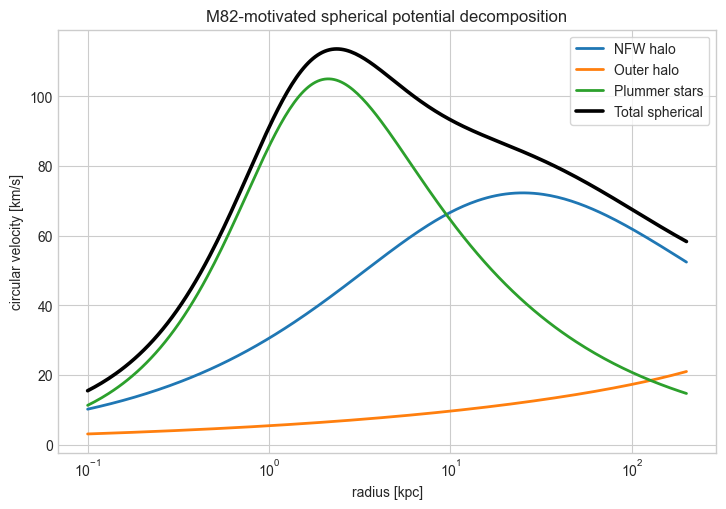

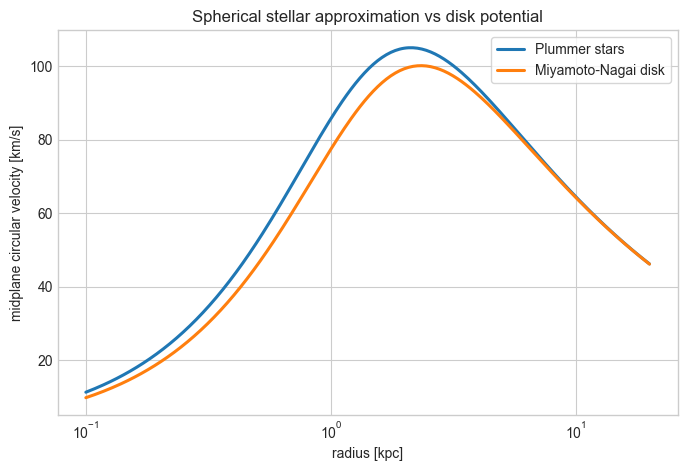

In [4]:
BASELINE_BUNDLE = build_m82_potential(DEFAULTS)
BASELINE_COOLING = build_cooling(DEFAULTS)

plot_potential_decomposition(BASELINE_BUNDLE)
plot_stellar_potential_comparison(BASELINE_BUNDLE)


## Sonic-radius sweep

We now hold the halo and cooling model fixed and sweep the sonic radius across a wide logarithmic range.
Successful solutions are kept as full inward+outward profiles. Requested radii that do not yield an accepted transonic
solution remain in the sweep metadata and will be marked explicitly in the `Mdot(R_sonic)` plot.


In [5]:
R_SONIC_GRID = np.geomspace(0.3, 120.0, 16)
R_MIN_KPC = 0.1
R_MAX_KPC = 200.0

baseline_sweep_records, baseline_sweep_rows = run_sonic_sweep(
    BASELINE_BUNDLE['spherical'],
    BASELINE_COOLING,
    R_SONIC_GRID,
    R_min_kpc=R_MIN_KPC,
    R_max_kpc=R_MAX_KPC,
    calc_inward_solution=True,
    max_step=0.1,
)

print_table(
    baseline_sweep_rows,
    columns=[
        'R_sonic_kpc',
        'success',
        'Mdot_Msun_per_yr',
        'stop_reason',
        'failure_reason',
        'outer_radius_kpc',
        'n_points',
    ],
)


R_sonic_kpc | success | Mdot_Msun_per_yr | stop_reason   | failure_reason | outer_radius_kpc | n_points
------------+---------+------------------+---------------+----------------+------------------+---------
0.300       | yes     | 0.026            | Max R reached |                | 200.000          | 96      
0.447       | yes     | 0.068            | Max R reached |                | 200.000          | 98      
0.667       | yes     | 0.199            | Max R reached |                | 200.000          | 99      
0.994       | yes     | 0.467            | Max R reached |                | 200.000          | 101     
1.483       | no      | 0.722            |               | Unbound        | 76.981           | 42      
2.210       | no      | 0.825            |               | Sonic point    | 2.392            | 8       
3.296       | no      | 0.817            |               | Unbound        | 32.935           | 26      
4.914       | no      | 0.797            |               | Unbou

/var/folders/sg/437fxmt53q9fmmkjc_m7ztzh0000gp/T/ipykernel_28930/2546358270.py:319: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


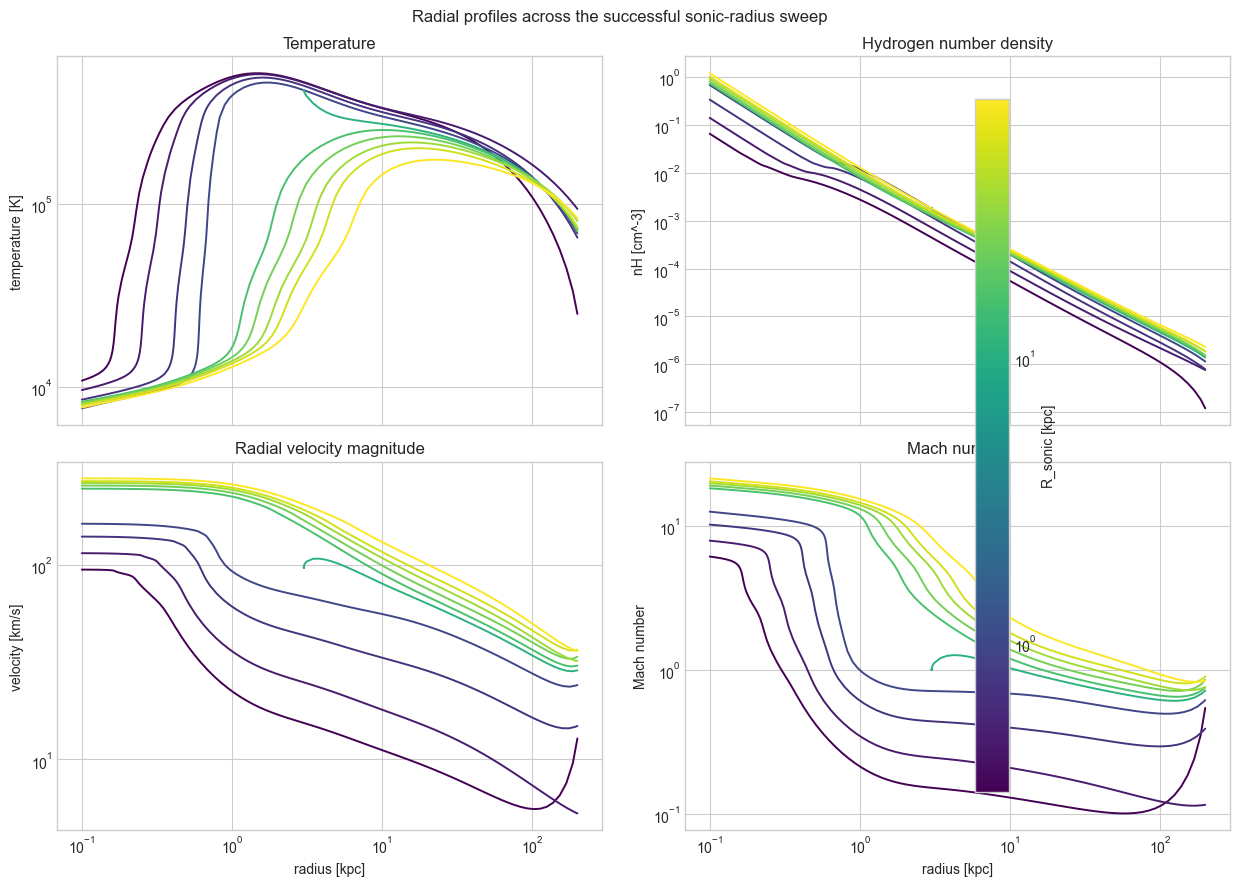

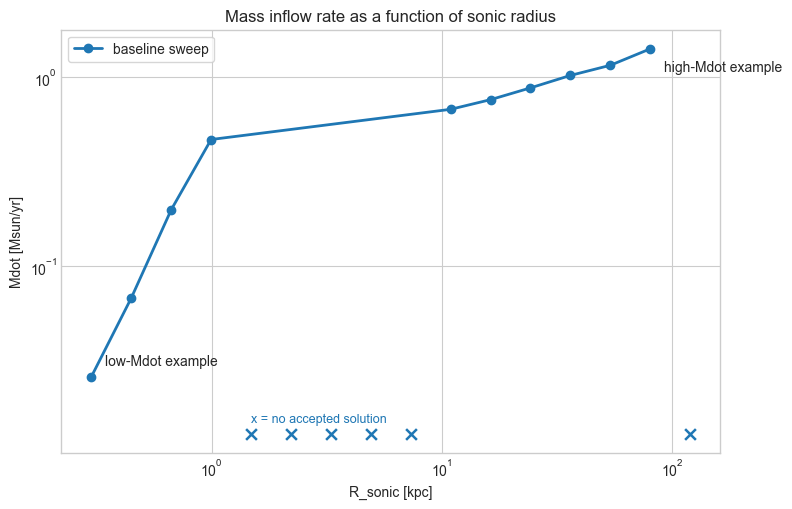

Successful solutions: 10 / 16
Mdot increases from 0.026 Msun/yr at R_sonic = 0.30 kpc to 1.405 Msun/yr at R_sonic = 80.48 kpc.
No accepted transonic solution at: 1.48 kpc, 2.21 kpc, 3.30 kpc, 4.91 kpc, 7.33 kpc, 120.00 kpc
Across the successful family, larger sonic radii generally correspond to hotter, denser, and more strongly accreting solutions in the outer halo, while the inner branch still shows a broad spread in Mach number and cooling-to-freefall behavior.


In [6]:
successful_records = [record for record in baseline_sweep_records if record['success']]
successful_records = sorted(successful_records, key=lambda record: record['R_sonic_kpc'])

low_mdot_record = min(successful_records, key=lambda record: record['Mdot_Msun_per_yr'])
high_mdot_record = max(successful_records, key=lambda record: record['Mdot_Msun_per_yr'])

plot_profile_family(successful_records, 'Radial profiles across the successful sonic-radius sweep')
plot_mdot_scaling(baseline_sweep_rows, low_mdot_record, high_mdot_record)

failed_radii = [row['R_sonic_kpc'] for row in baseline_sweep_rows if not row['success']]
print(f'Successful solutions: {len(successful_records)} / {len(baseline_sweep_rows)}')
print(
    'Mdot increases from '
    f"{low_mdot_record['Mdot_Msun_per_yr']:.3f} Msun/yr at R_sonic = {low_mdot_record['R_sonic_kpc']:.2f} kpc "
    f"to {high_mdot_record['Mdot_Msun_per_yr']:.3f} Msun/yr at R_sonic = {high_mdot_record['R_sonic_kpc']:.2f} kpc."
)
if failed_radii:
    print('No accepted transonic solution at:', ', '.join(f'{value:.2f} kpc' for value in failed_radii))
print(
    'Across the successful family, larger sonic radii generally correspond to hotter, denser, and more strongly '
    'accreting solutions in the outer halo, while the inner branch still shows a broad spread in Mach number and '
    'cooling-to-freefall behavior.'
)


## Low- and high-`Mdot` examples

To move from the family overview to individual solutions, we now pick the successful sweep members with the smallest
and largest mass inflow rates and inspect their radial structure in more detail.


label             | R_sonic_kpc | Mdot_Msun_per_yr | outer_radius_kpc | min_tcool_to_tff | peak_mach | cooling_radius_at_1Gyr_kpc
------------------+-------------+------------------+------------------+------------------+-----------+---------------------------
Low Mdot example  | 0.300       | 0.026            | 200.000          | 0.016            | 6.102     | 10.415                    
High Mdot example | 80.484      | 1.405            | 200.000          | 0.026            | 21.282    | 55.147                    


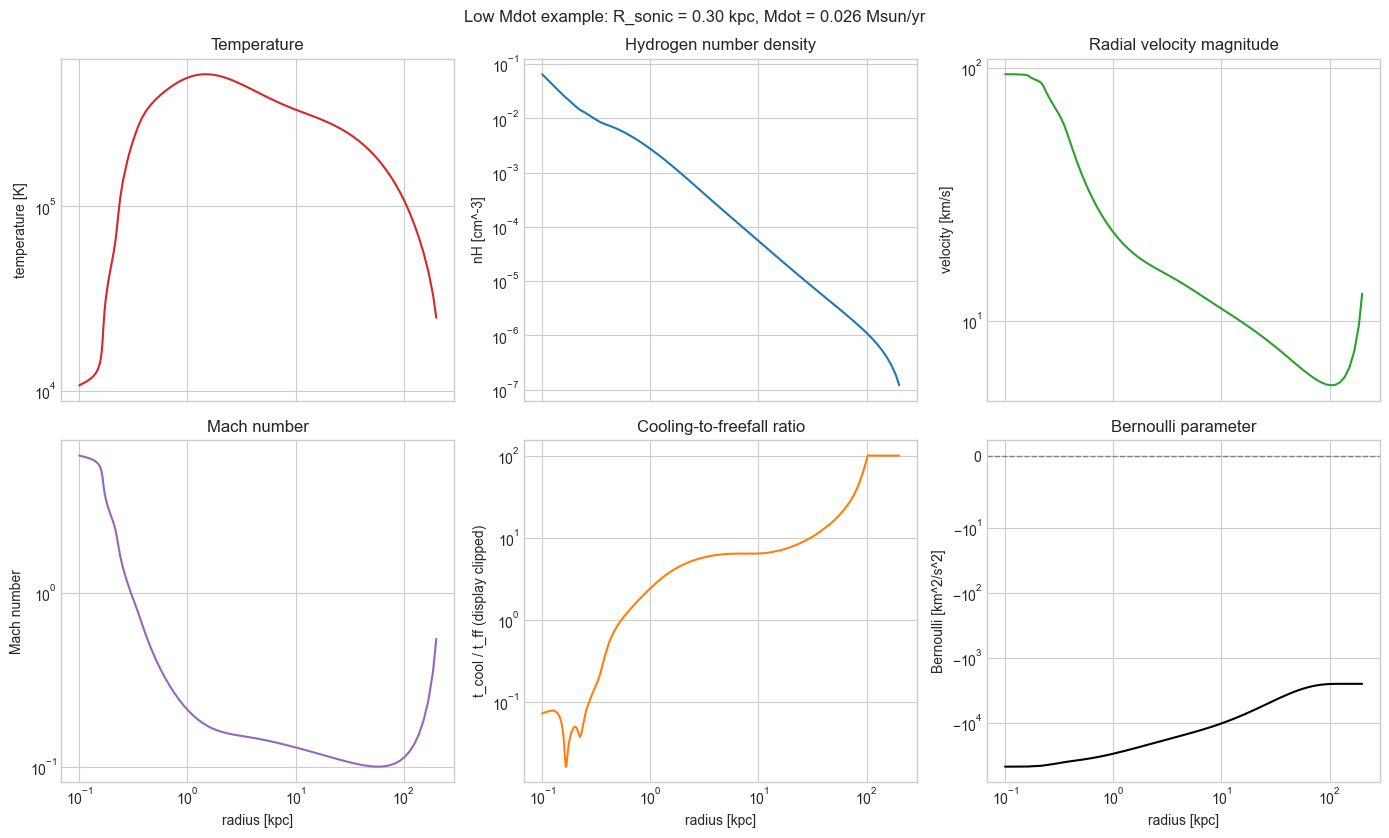

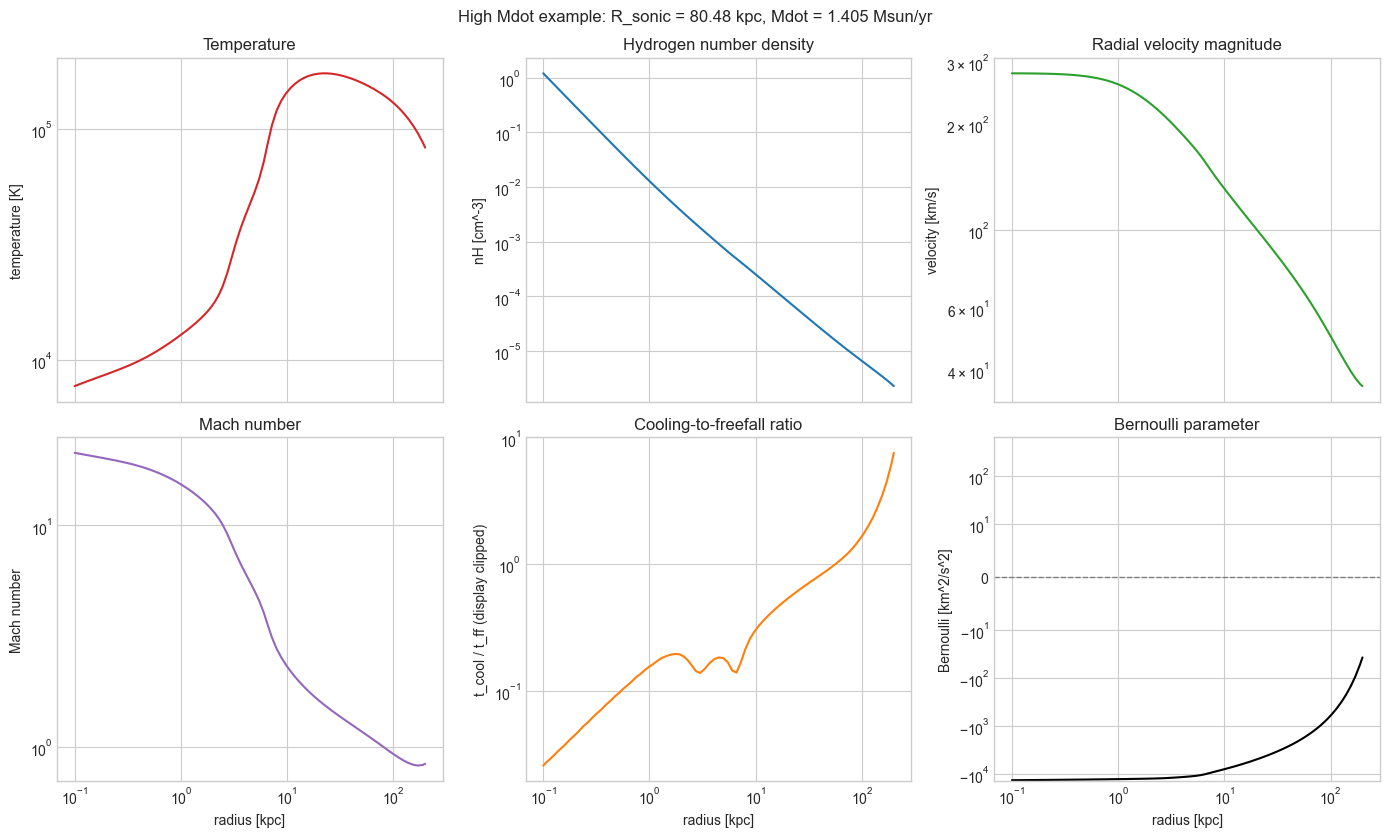

In [7]:
example_records = {
    'Low Mdot example': low_mdot_record,
    'High Mdot example': high_mdot_record,
}

comparison_rows = [
    summarize_solution(label, record, reference_time_Gyr=1.0)
    for label, record in example_records.items()
]
print_table(
    comparison_rows,
    columns=[
        'label',
        'R_sonic_kpc',
        'Mdot_Msun_per_yr',
        'outer_radius_kpc',
        'min_tcool_to_tff',
        'peak_mach',
        'cooling_radius_at_1Gyr_kpc',
    ],
)

plot_detailed_solution('Low Mdot example', low_mdot_record)
plot_detailed_solution('High Mdot example', high_mdot_record)


## Balanced parameter variations

We now vary a small set of physically meaningful parameters around the M82-motivated baseline and ask how the
`Mdot(R_sonic)` relation responds. This stays focused on the main halo/cooling levers without turning the notebook into
a broad parameter survey.


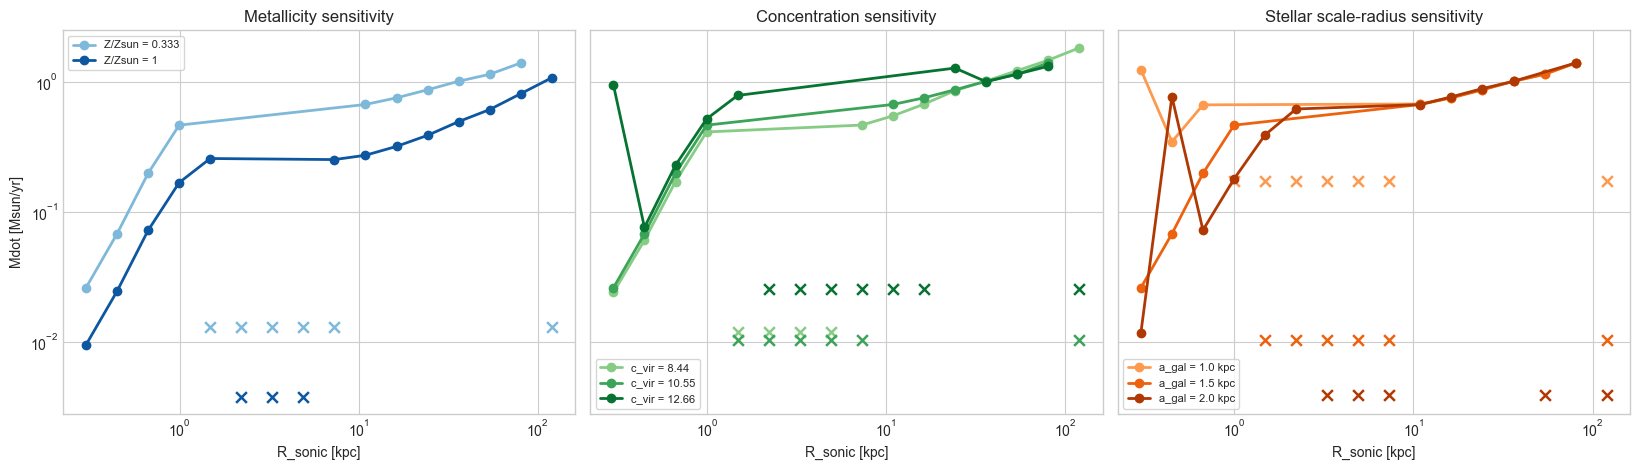

In [8]:
c_base = DEFAULTS['c_vir']
concentration_values = [0.8 * c_base, c_base, 1.2 * c_base]
stellar_scale_values = [1.0, DEFAULTS['a_gal_kpc'], 2.0]
metallicity_values = [DEFAULTS['metallicity_solar'], 1.0]

metallicity_cases = []
for metallicity_solar in metallicity_values:
    cooling = build_cooling(DEFAULTS, metallicity_solar=metallicity_solar)
    _, rows = run_sonic_sweep(
        BASELINE_BUNDLE['spherical'],
        cooling,
        R_SONIC_GRID,
        R_min_kpc=R_MIN_KPC,
        R_max_kpc=R_MAX_KPC,
        calc_inward_solution=True,
        max_step=0.1,
    )
    metallicity_cases.append((f'Z/Zsun = {metallicity_solar:.3g}', rows))

concentration_cases = []
for c_value in concentration_values:
    bundle = build_m82_potential(DEFAULTS, c_vir=c_value)
    _, rows = run_sonic_sweep(
        bundle['spherical'],
        BASELINE_COOLING,
        R_SONIC_GRID,
        R_min_kpc=R_MIN_KPC,
        R_max_kpc=R_MAX_KPC,
        calc_inward_solution=True,
        max_step=0.1,
    )
    concentration_cases.append((f'c_vir = {c_value:.2f}', rows))

stellar_scale_cases = []
for a_gal_kpc in stellar_scale_values:
    bundle = build_m82_potential(DEFAULTS, a_gal_kpc=a_gal_kpc)
    _, rows = run_sonic_sweep(
        bundle['spherical'],
        BASELINE_COOLING,
        R_SONIC_GRID,
        R_min_kpc=R_MIN_KPC,
        R_max_kpc=R_MAX_KPC,
        calc_inward_solution=True,
        max_step=0.1,
    )
    stellar_scale_cases.append((f'a_gal = {a_gal_kpc:.1f} kpc', rows))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), sharey=True)
color_sets = [plt.cm.Blues(np.linspace(0.45, 0.85, len(metallicity_cases))),
              plt.cm.Greens(np.linspace(0.45, 0.85, len(concentration_cases))),
              plt.cm.Oranges(np.linspace(0.45, 0.85, len(stellar_scale_cases)))]

for ax, title, cases, colors in zip(
    axes,
    ['Metallicity sensitivity', 'Concentration sensitivity', 'Stellar scale-radius sensitivity'],
    [metallicity_cases, concentration_cases, stellar_scale_cases],
    color_sets,
):
    for idx, ((label, rows), color) in enumerate(zip(cases, colors)):
        plot_mdot_series(ax, rows, label=label, color=color, failure_scale=1.0 + 0.25 * idx)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R_sonic [kpc]')
    ax.set_title(title)
    ax.legend(frameon=True, fontsize=8)
axes[0].set_ylabel('Mdot [Msun/yr]')
fig.tight_layout()
plt.show()
plt.close(fig)


## Rotation diagnostics

Rotation is layered onto the 1D inflow solution analytically through `RotationConfig`.
Here we evaluate three circularization radii for both the low- and high-`Mdot` examples and compare the inferred
rotational speed, winding ratio, and total rotation angle before accretion.


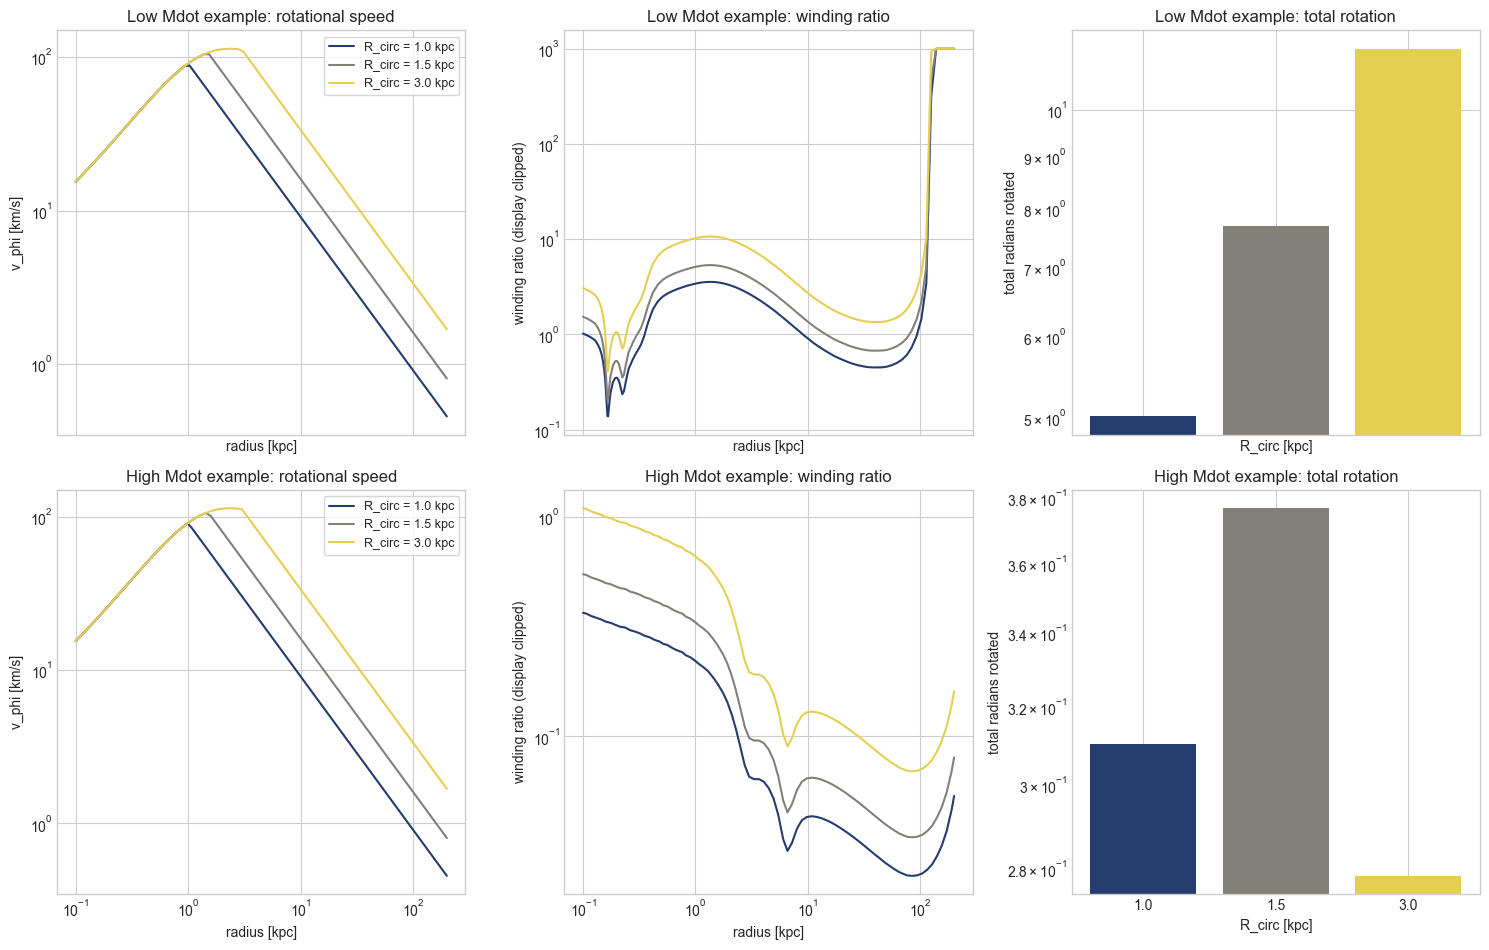

R_circ_kpc | v_c_at_R_circ_kms | Mdot_hot_max_Msun_per_yr
-----------+-------------------+-------------------------
1.000      | 91.117            | 0.114                   
1.500      | 107.240           | 0.412                   
3.000      | 112.257           | 1.054                   


In [9]:
R_CIRC_VALUES = [1.0, 1.5, 3.0]
rotation_context_rows = plot_rotation_diagnostics(example_records, R_CIRC_VALUES, DEFAULTS)
print_table(rotation_context_rows, columns=['R_circ_kpc', 'v_c_at_R_circ_kms', 'Mdot_hot_max_Msun_per_yr'])


## Turbulence diagnostics

Turbulence is also layered onto the 1D solution analytically.
We keep the default turbulence model parameters fixed and vary only the transition threshold between the hot-inflow
and turbulence-dominated regimes.


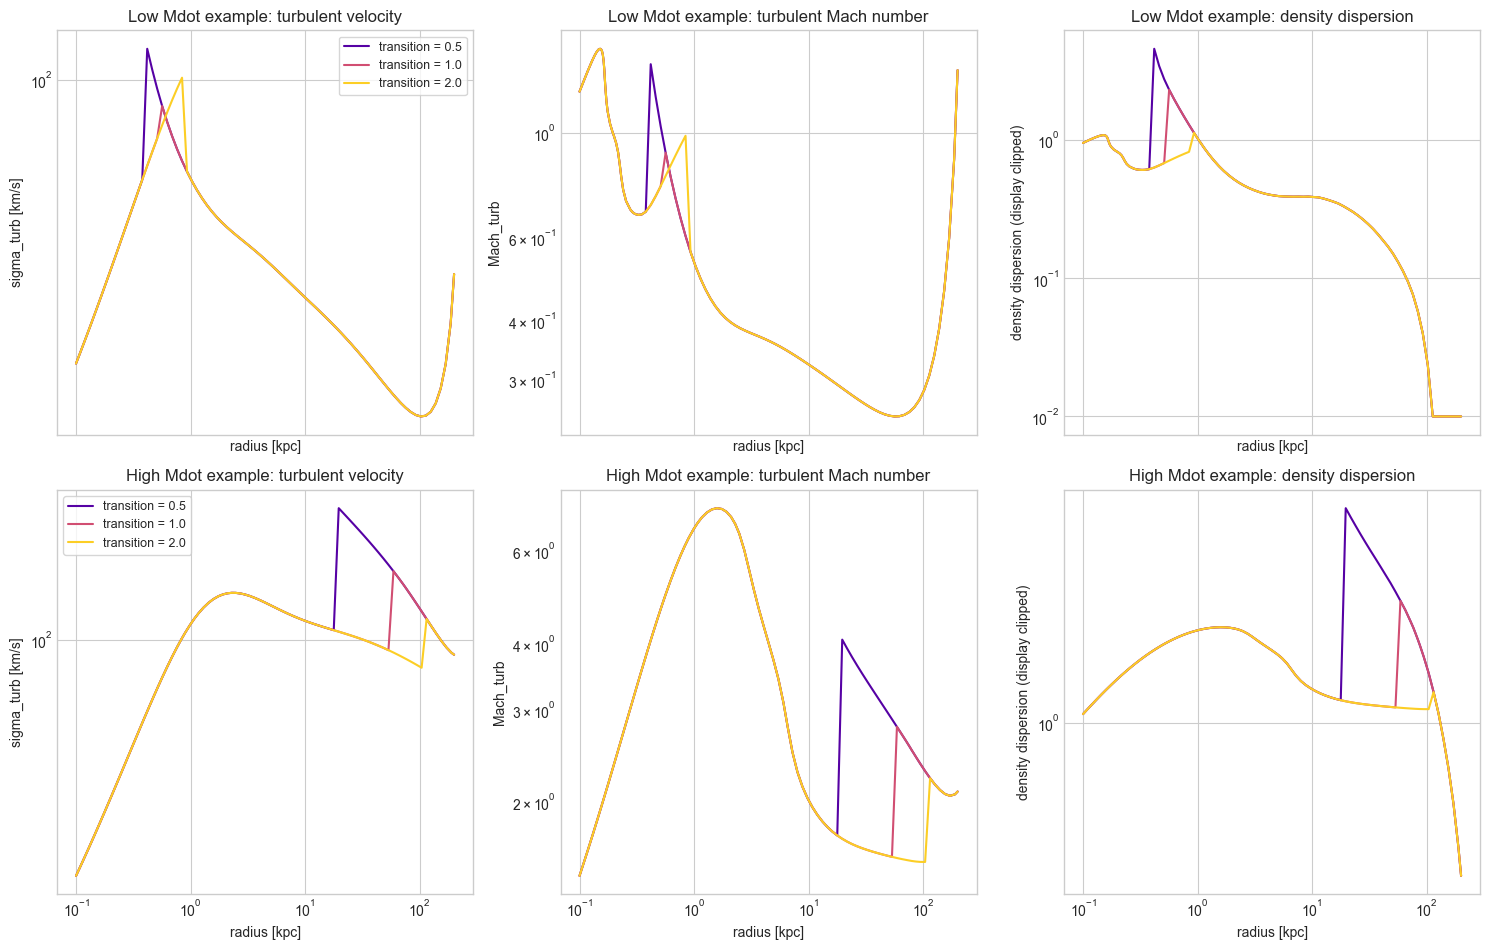

In [10]:
TRANSITION_VALUES = [0.5, 1.0, 2.0]
plot_turbulence_diagnostics(example_records, TRANSITION_VALUES)


## Takeaways

- This M82-motivated baseline combines a `10^11 Msun` halo, a compact `10^10 Msun` stellar component, and a
  metal-poor-but-still-enriched cooling curve with `Z/Zsun = 1/3`.
- In the successful branch of the sonic-radius sweep, `Mdot` grows strongly with increasing `R_sonic`, while a gap of
  no accepted transonic solutions appears at intermediate sonic radii for this baseline potential and cooling setup.
- The low- and high-`Mdot` examples differ not only in inflow rate, but also in their Mach structure and their
  cooling-to-freefall balance across the halo.
- Rotation and turbulence here are diagnostic layers on top of the 1D flow solution, not self-consistent feedback
  terms in the ODE integration.
- The spherical Plummer stellar component is used for the cooling-flow solver, while the Miyamoto-Nagai disk gives the
  simulation-facing comparison for the stellar potential.
